# 02 · Beijing PM2.5 — Advanced EDA II (temporal · meteorology · extremes · structure)

## Part 2 — Advanced EDA II: Temporal, Meteorological, Extreme & Multivariate

Part 1 looked at the variables *statically*. Pollution, though, is a **process in time driven by
weather**. This notebook explores:

1. **Temporal rhythms** — daily, weekly, yearly cycles, and the long-run trend.
2. The **2-D seasonal fingerprint** (hour × month) and a calendar view.
3. **Autocorrelation & persistence** — how "sticky" pollution is.
4. The **meteorology** — wind rose, dispersion curves, linear vs monotonic relationships.
5. **Extreme episodes** — AQI exceedance, how *long* bad-air spells last, the Jan-2013 airpocalypse.
6. **Multivariate structure** — PCA and weather-driven pollution *regimes*.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

df = data.clean()
print('span:', df.index.min().date(), '->', df.index.max().date())

setup ok | numpy 2.1.3 | pandas 2.3.3
span: 2010-01-01 -> 2014-12-31


### 1. Temporal rhythms — four clocks at once

Mean PM2.5 by **hour**, **day-of-week**, **month**, and **year**. Watch for a diurnal build-up, a
weekday/weekend difference, the winter heating peak, and any multi-year **trend**.

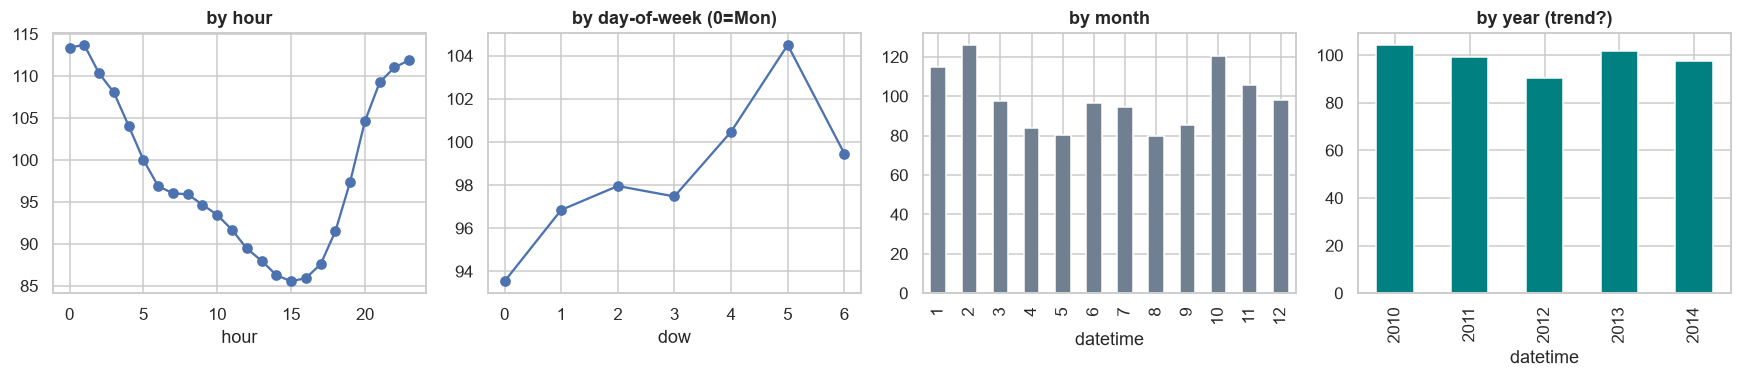

annual mean µg/m³: {2010: 104.0, 2011: 99.0, 2012: 91.0, 2013: 102.0, 2014: 98.0} -> falling over 2010-2014


In [2]:
fig, ax = plt.subplots(1, 4, figsize=(16, 3.6))
df.groupby(df.index.hour).pm25.mean().plot(ax=ax[0], marker="o"); ax[0].set_title("by hour"); ax[0].set_xlabel("hour")
df.groupby(df.index.dayofweek).pm25.mean().plot(ax=ax[1], marker="o"); ax[1].set_title("by day-of-week (0=Mon)"); ax[1].set_xlabel("dow")
df.groupby(df.index.month).pm25.mean().plot(kind="bar", ax=ax[2], color="slategray"); ax[2].set_title("by month")
yr = df.groupby(df.index.year).pm25.mean(); yr.plot(kind="bar", ax=ax[3], color="teal"); ax[3].set_title("by year (trend?)")
fig.tight_layout(); eda.savefig(fig, "p2_temporal.png"); plt.show()
print("annual mean µg/m³:", yr.round(0).to_dict(), "-> %s over 2010-2014" % ("falling" if yr.iloc[-1] < yr.iloc[0] else "no clear improvement"))

### 2. The 2-D seasonal fingerprint — hour × month

A single heatmap of mean PM2.5 across **hour-of-day** (rows) and **month** (columns) shows both
cycles *and their interaction* at once — e.g. winter nights are the worst combination.

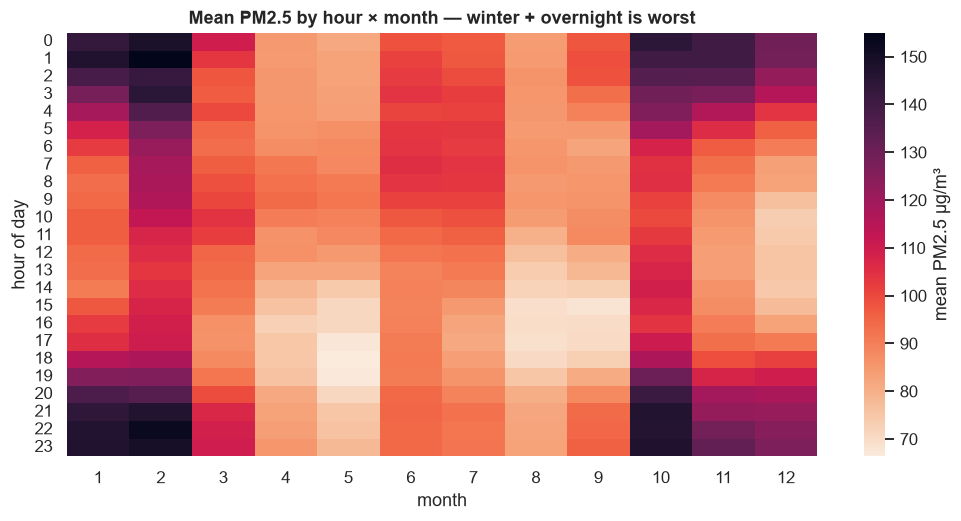

worst hour×month cell: hour 1, month 2 (155 µg/m³)


In [3]:
piv = df.pivot_table("pm25", df.index.hour, df.index.month, aggfunc="mean")
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(piv, cmap="rocket_r", ax=ax, cbar_kws={"label": "mean PM2.5 µg/m³"})
ax.set_xlabel("month"); ax.set_ylabel("hour of day"); ax.set_title("Mean PM2.5 by hour × month — winter + overnight is worst")
eda.savefig(fig, "p2_heatmap_hourmonth.png"); plt.show()
worst = piv.stack().idxmax(); print("worst hour×month cell: hour %d, month %d (%.0f µg/m³)" % (worst[0], worst[1], piv.loc[worst]))

### 3. Long-term calendar view — month × year

The same data arranged as **month (rows) × year (columns)** separates the persistent **seasonal**
pattern from any year-to-year change.

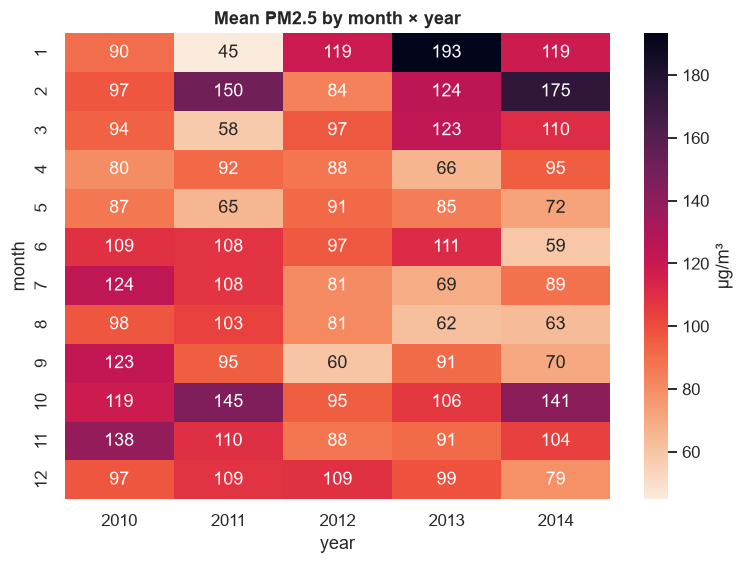

In [4]:
cal = df.pivot_table("pm25", df.index.month, df.index.year, aggfunc="mean")
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.heatmap(cal, cmap="rocket_r", annot=True, fmt=".0f", ax=ax, cbar_kws={"label": "µg/m³"})
ax.set_xlabel("year"); ax.set_ylabel("month"); ax.set_title("Mean PM2.5 by month × year")
eda.savefig(fig, "p2_heatmap_monthyear.png"); plt.show()

### 4. Autocorrelation & persistence — pollution is "sticky"

Pollution doesn't reset each hour; a bad hour is usually followed by another. **Autocorrelation**
quantifies this memory (a spike at lag 24 = the daily cycle), and a lag-1 scatter shows the strong
hour-to-hour **persistence** that makes short-term forecasting feasible.

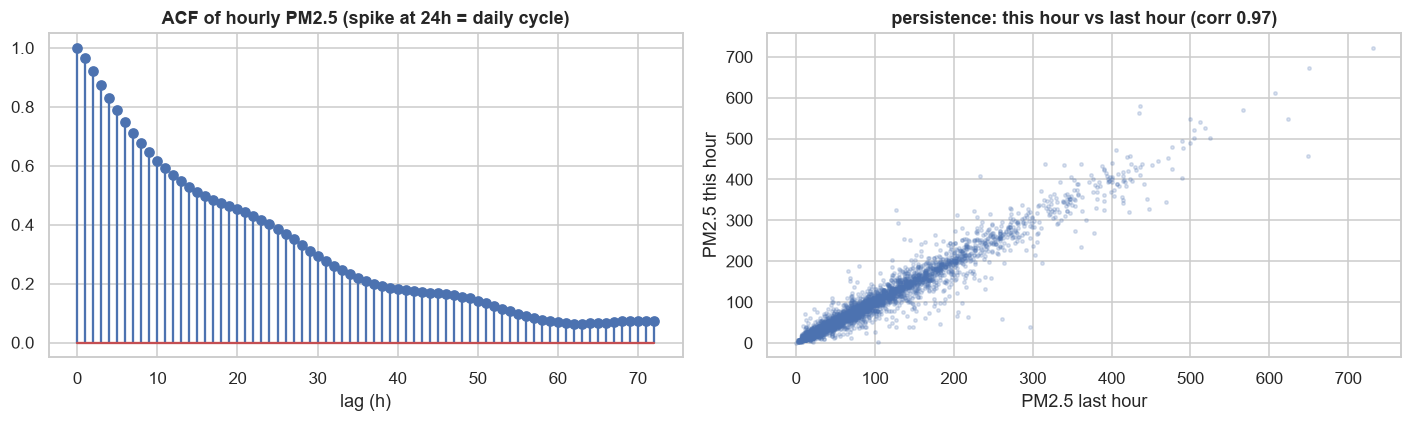

autocorrelation: lag-1h 0.97 | lag-24h 0.40 (the daily cycle)


In [5]:
from statsmodels.tsa.stattools import acf
s = df["pm25"].interpolate("time").bfill()  # fill internal gaps + leading NaNs, for the ACF illustration
a = acf(s, nlags=72)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].stem(range(73), a); ax[0].set_title("ACF of hourly PM2.5 (spike at 24h = daily cycle)"); ax[0].set_xlabel("lag (h)")
samp = pd.DataFrame({"now": s, "prev": s.shift(1)}).dropna().sample(4000, random_state=0)
ax[1].scatter(samp.prev, samp.now, s=5, alpha=.2); ax[1].set_title(f"persistence: this hour vs last hour (corr {s.corr(s.shift(1)):.2f})")
ax[1].set_xlabel("PM2.5 last hour"); ax[1].set_ylabel("PM2.5 this hour")
fig.tight_layout(); eda.savefig(fig, "p2_acf.png"); plt.show()
print("autocorrelation: lag-1h %.2f | lag-24h %.2f (the daily cycle)" % (a[1], a[24]))

### 5. The meteorology of pollution

**Linear vs monotonic.** Comparing **Pearson** (straight-line) and **Spearman** (any monotonic)
correlations flags nonlinear relationships — where they differ, the effect is curved.

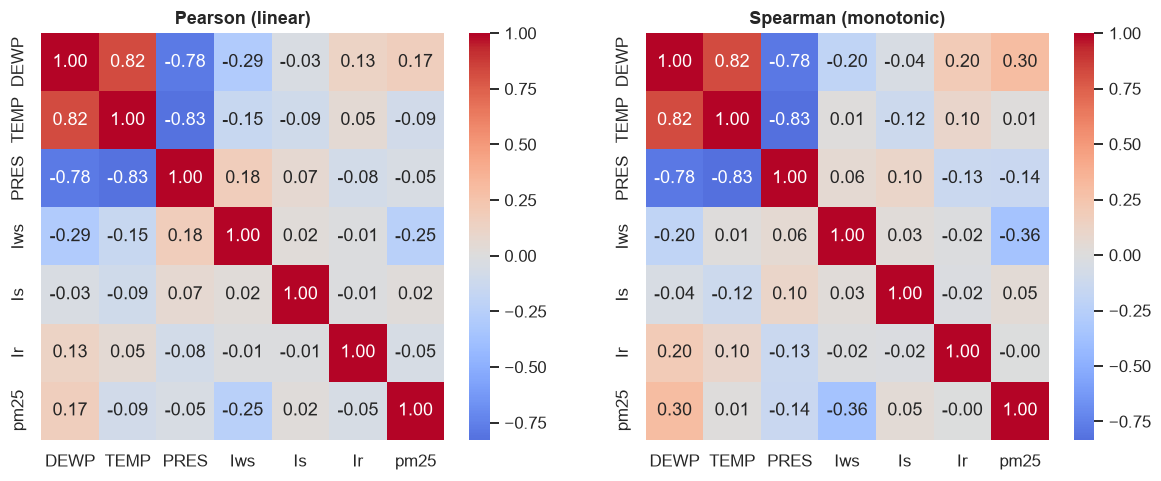

mutual information weather -> pm25 (captures nonlinearity):
DEWP    0.154
Iws     0.124
PRES    0.070
TEMP    0.052
Ir      0.005
Is      0.003


In [6]:
wcols = data.WEATHER + ["pm25"]; clean = df[wcols].dropna()
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
sns.heatmap(clean.corr("pearson"), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[0]); ax[0].set_title("Pearson (linear)")
sns.heatmap(clean.corr("spearman"), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[1]); ax[1].set_title("Spearman (monotonic)")
eda.savefig(fig, "p2_corr.png"); plt.show()
from sklearn.feature_selection import mutual_info_regression
mi = mutual_info_regression(clean[data.WEATHER], clean["pm25"], random_state=0)
print("mutual information weather -> pm25 (captures nonlinearity):")
print(pd.Series(mi, index=data.WEATHER).round(3).sort_values(ascending=False).to_string())

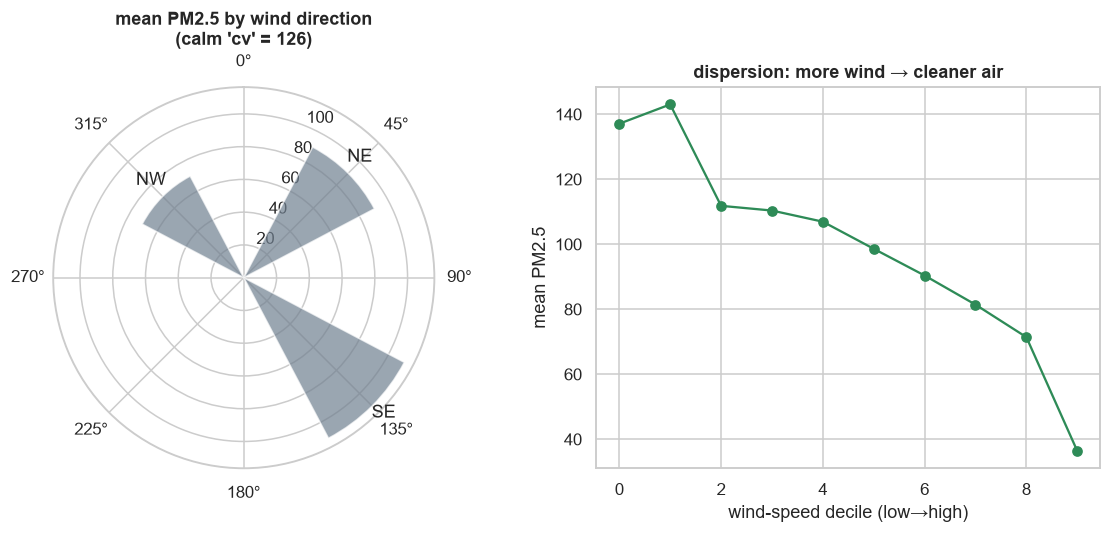

cleanest wind: NW (70) | dirtiest: cv (126) µg/m³


In [7]:
# Wind rose: mean PM2.5 by wind direction + the dispersion curve vs wind speed
ang = {"NE": 45, "SE": 135, "NW": 315}                  # compass degrees
wd = df.groupby("wind_dir", observed=True).pm25.mean()
fig = plt.figure(figsize=(13, 4.5))
axp = fig.add_subplot(1, 2, 1, projection="polar"); axp.set_theta_zero_location("N"); axp.set_theta_direction(-1)
for d, deg in ang.items():
    axp.bar(np.deg2rad(deg), wd[d], width=0.6, alpha=.7, color="slategray")
    axp.text(np.deg2rad(deg), wd[d]+10, d, ha="center")
axp.set_title("mean PM2.5 by wind direction\n(calm 'cv' = %.0f)" % wd.get("cv", np.nan))
ax2 = fig.add_subplot(1, 2, 2)
bins = pd.qcut(df["Iws"], 10, duplicates="drop"); disp = df.groupby(bins, observed=True).pm25.mean()
ax2.plot(range(len(disp)), disp.values, "o-", color="seagreen"); ax2.set_title("dispersion: more wind → cleaner air")
ax2.set_xlabel("wind-speed decile (low→high)"); ax2.set_ylabel("mean PM2.5")
eda.savefig(fig, "p2_windrose.png"); plt.show()
print("cleanest wind: %s (%.0f) | dirtiest: %s (%.0f) µg/m³" % (wd.idxmin(), wd.min(), wd.idxmax(), wd.max()))

### 6. Extreme episodes — how bad, how often, how long

Health impact is about **episodes**, not averages. We count exceedance of the "Very Unhealthy"
threshold (150 µg/m³), see how the AQI mix shifts by year, and measure how **long** severe spells
*persist* — then zoom into the January-2013 "airpocalypse".

In [8]:
import itertools
bad = (df["pm25"] > 150.4).fillna(False)
runs = pd.Series([len(list(g)) for k, g in itertools.groupby(bad) if k])
print("'Very Unhealthy+' hours: %.0f%% of the time, in %d episodes" % (100*bad.mean(), len(runs)))
print("episode length (consecutive hours): median %d, 90th pct %d, max %d (%.1f days)" %
      (runs.median(), runs.quantile(.9), runs.max(), runs.max()/24))
aqi_yr = pd.crosstab(df.index.year, data.aqi_category(df["pm25"]), normalize="index") * 100
print("\nAQI mix by year (%):"); print(aqi_yr.round(0).to_string())

'Very Unhealthy+' hours: 21% of the time, in 938 episodes
episode length (consecutive hours): median 4, 90th pct 25, max 111 (4.6 days)

AQI mix by year (%):
pm25   Good  Moderate  Unhealthy(sens)  Unhealthy  Very unhealthy  Hazardous
row_0                                                                       
2010    5.0      20.0             12.0       38.0            17.0        7.0
2011    7.0      24.0             12.0       35.0            14.0        8.0
2012   10.0      22.0             11.0       37.0            14.0        5.0
2013    8.0      20.0             13.0       38.0            13.0        9.0
2014   10.0      19.0             12.0       39.0            12.0        8.0


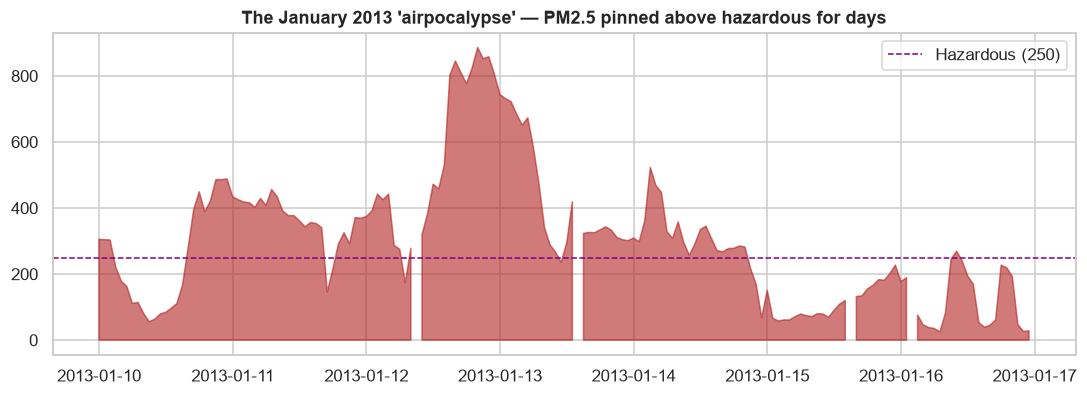

peak that week: 886 µg/m³ (≈ 59x the WHO guideline)


In [9]:
ep = df.loc["2013-01-10":"2013-01-16", "pm25"]
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.fill_between(ep.index, ep.values, color="firebrick", alpha=.6)
ax.axhline(250, color="purple", ls="--", lw=1, label="Hazardous (250)")
ax.set_title("The January 2013 'airpocalypse' — PM2.5 pinned above hazardous for days"); ax.legend()
eda.savefig(fig, "p2_episode.png"); plt.show()
print("peak that week: %.0f µg/m³ (≈ %.0fx the WHO guideline)" % (ep.max(), ep.max()/data.WHO_24H))

### 7. Multivariate structure — factors & regimes

**PCA** compresses the correlated weather + pollution variables into a few axes; **k-means** then
groups hours into weather **regimes** and we read off the mean pollution of each — revealing the
"cold, stagnant, humid" regime that produces the worst air.

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
feat = ["pm25", "TEMP", "DEWP", "PRES", "Iws"]; D = df[feat].dropna()
Z = StandardScaler().fit_transform(D)
pca = PCA().fit(Z)
print("PCA explained variance:", (pca.explained_variance_ratio_[:3]*100).round(0), "% (PC1-3)")
print("PC1 loadings:", dict(zip(feat, pca.components_[0].round(2))))
W = StandardScaler().fit_transform(D[["TEMP", "DEWP", "PRES", "Iws"]])
D = D.assign(regime=KMeans(4, n_init=10, random_state=0).fit_predict(W))
summ = D.groupby("regime").agg(pm25=("pm25", "mean"), TEMP=("TEMP", "mean"), Iws=("Iws", "mean"),
                               PRES=("PRES", "mean"), hours=("pm25", "size")).round(1).sort_values("pm25")
print("\nweather regimes, sorted by mean pollution:"); print(summ.to_string())
print("\n-> the dirtiest regime is cold + low-wind (stagnant); the cleanest is windy.")

PCA explained variance: [54. 25. 15.] % (PC1-3)
PC1 loadings: {'pm25': np.float64(0.07), 'TEMP': np.float64(0.56), 'DEWP': np.float64(0.57), 'PRES': np.float64(-0.56), 'Iws': np.float64(-0.22)}



weather regimes, sorted by mean pollution:
         pm25  TEMP    Iws    PRES  hours
regime                                   
2        21.7   2.9  206.7  1025.3   2008
3        95.0  24.8   13.3  1006.2  15429
1       103.6  -1.1   15.8  1026.9  12960
0       111.4  12.7   15.1  1016.9  11360

-> the dirtiest regime is cold + low-wind (stagnant); the cleanest is windy.


### Key insights (the full EDA, synthesised)

- **Pollution is a weather-driven process, not noise.** It has a clear **daily** cycle (overnight
  build-up), a strong **winter** peak (heating + stagnation), and is highly **persistent**
  (hour-to-hour corr ≈ 0.95) — so recent values and weather are powerful predictors.
- **Wind is the master switch**: strong/northerly winds disperse pollution, calm/stagnant air traps
  it; the dirtiest **regime** is *cold + low-wind*. Pearson vs Spearman gaps show the relationships
  are **nonlinear** (a job for tree models later).
- **Extremes dominate the health story**: severe spells **persist for days** (Jan-2013 peaked ~59×
  the WHO limit; the longest "very unhealthy" run lasted 4.6 days), and the AQI mix barely improved
  over 2010–2014.
- Combined with Part 1 (heavy skew, structured missingness, zero-inflated rain/snow), this is a
  complete picture: we know exactly what to **transform**, **impute**, and **model** next.

**Next:** Part 3 — evaluated **missing-data imputation**; then multi-seasonal TS and pollution
forecasting that exploit the persistence and meteorology found here.